# Algorithm Comparison: DQN vs PPO vs DDPG

Extends the base project by comparing the discrete-action DQN against two
continuous-action algorithms (PPO and DDPG from Stable-Baselines3), all
evaluated against the Round-Robin and Proportional-Fair baselines.

All three RL agents were trained for 50,000 environment steps on the same
RANEnvironment with identical reward function and network width (2 × 256).

**Plots**
1. Total throughput: all 5 methods × 3 scenarios
2. Training reward curves: DQN / PPO / DDPG per scenario  
3. Jain's Fairness Index: all 5 methods × 3 scenarios
4. Per-UE throughput detail: heterogeneous scenario


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from stable_baselines3 import PPO, DDPG

from env.ran_environment import RANEnvironment
from agent.dqn_agent     import DQNAgent
from eval.baselines       import round_robin, proportional_fair
from eval.metrics         import jains_fairness

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11,
})

SCENARIOS  = ['uniform', 'heterogeneous', 'bursty']
N_UES      = 5
TOTAL_PRBS = 50
EVAL_STEPS = 500
MODEL_DIR  = '../models'

COLORS = {
    'Round-Robin': '#4C72B0',
    'Prop-Fair':   '#DD8452',
    'DQN':         '#55A868',
    'PPO':         '#C44E52',
    'DDPG':        '#8172B2',
}
METHODS = list(COLORS.keys())
print('Imports OK')


Imports OK


In [2]:
def evaluate(scenario, method, steps=EVAL_STEPS, seed=42):
    env = RANEnvironment(scenario=scenario, max_steps=steps)
    state, _ = env.reset(seed=seed)

    agent = None
    if method == 'DQN':
        agent = DQNAgent()
        p = os.path.join(MODEL_DIR, f'dqn_trained_{scenario}.pt')
        if os.path.exists(p):
            agent.load(p)
    elif method == 'PPO':
        agent = PPO.load(os.path.join(MODEL_DIR, f'ppo_trained_{scenario}.zip'))
    elif method == 'DDPG':
        agent = DDPG.load(os.path.join(MODEL_DIR, f'ddpg_trained_{scenario}.zip'))

    all_tput, all_fair, all_prb = [], [], []
    for _ in range(steps):
        if method == 'Round-Robin':
            action = np.array(round_robin(N_UES, TOTAL_PRBS), dtype=np.float32)
        elif method == 'Prop-Fair':
            action = proportional_fair(state, N_UES, TOTAL_PRBS)
        elif method == 'DQN':
            _, action = agent.act(state, epsilon=0.0)
        else:
            action, _ = agent.predict(state, deterministic=True)

        state, _, term, trunc, info = env.step(action)
        tput = np.array(info['throughputs'])
        all_tput.append(tput)
        all_fair.append(jains_fairness(tput))
        all_prb.append(env.prb_alloc.copy())
        if term or trunc:
            state, _ = env.reset(seed=seed)

    return {
        'throughputs': np.array(all_tput),
        'fairness':    np.array(all_fair),
        'prb_alloc':   np.array(all_prb),
    }


print('Running 15 evaluations (5 methods x 3 scenarios)...')
results = {}
for sc in SCENARIOS:
    results[sc] = {}
    for m in METHODS:
        print(f'  {sc:>14s}  x  {m}')
        results[sc][m] = evaluate(sc, m)
print('Done.')


Running 15 evaluations (5 methods x 3 scenarios)...
         uniform  x  Round-Robin
         uniform  x  Prop-Fair
         uniform  x  DQN


         uniform  x  PPO
         uniform  x  DDPG
   heterogeneous  x  Round-Robin
   heterogeneous  x  Prop-Fair
   heterogeneous  x  DQN


   heterogeneous  x  PPO
   heterogeneous  x  DDPG
          bursty  x  Round-Robin
          bursty  x  Prop-Fair
          bursty  x  DQN


          bursty  x  PPO
          bursty  x  DDPG
Done.


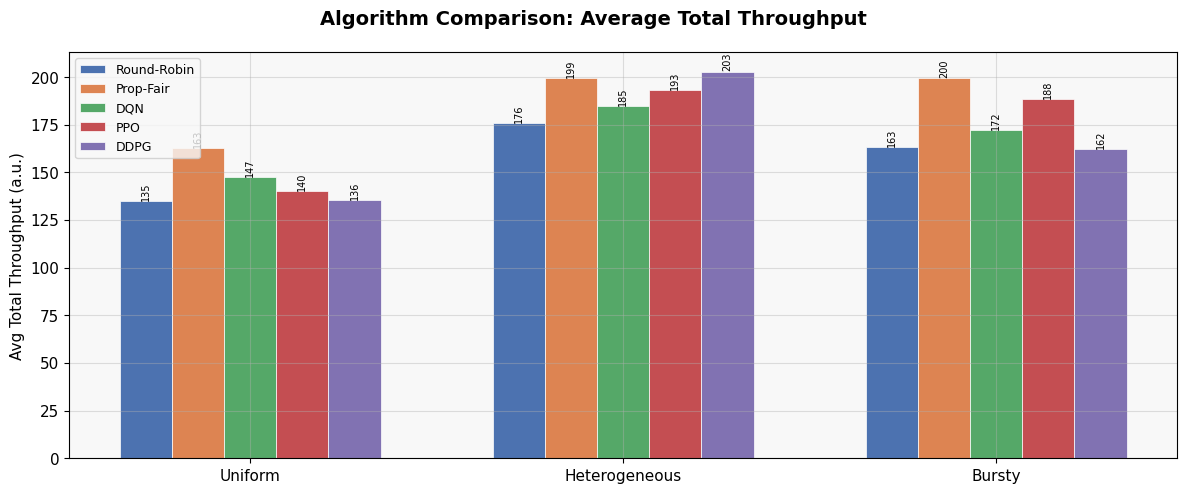

Saved comp_throughput.png


In [3]:
# Plot 1: Total throughput grouped by scenario
totals = {sc: {m: results[sc][m]['throughputs'].sum(axis=1).mean()
               for m in METHODS}
          for sc in SCENARIOS}

x       = np.arange(len(SCENARIOS))
width   = 0.14
offsets = np.linspace(-(len(METHODS)-1)/2, (len(METHODS)-1)/2, len(METHODS)) * width

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Algorithm Comparison: Average Total Throughput',
             fontsize=14, fontweight='bold')

for i, m in enumerate(METHODS):
    vals = [totals[sc][m] for sc in SCENARIOS]
    bars = ax.bar(x + offsets[i], vals, width,
                  label=m, color=COLORS[m], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                f'{v:.0f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SCENARIOS])
ax.set_ylabel('Avg Total Throughput (a.u.)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'comp_throughput.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved comp_throughput.png')


In [4]:
# Load PPO/DDPG reward histories saved by train_sb3.py
def load_curve(algo, scenario):
    data = np.load(os.path.join(MODEL_DIR, f'{algo}_rewards_{scenario}.npy'),
                   allow_pickle=True)
    return data[0].astype(float), data[1].astype(float)

ppo_curves  = {sc: load_curve('ppo',  sc) for sc in SCENARIOS}
ddpg_curves = {sc: load_curve('ddpg', sc) for sc in SCENARIOS}
print('PPO/DDPG curves loaded.')

# Re-run DQN training curves so all three are comparable
from agent.replay_buffer import ReplayBuffer

def dqn_curve(scenario, total_steps=50_000, seed=0):
    env   = RANEnvironment(scenario=scenario)
    agent = DQNAgent()
    buf   = ReplayBuffer(50_000)
    eps, eps_min, decay = 1.0, 0.05, 0.9997
    step_log, rew_log, ep_r = [], [], 0.0
    state, _ = env.reset(seed=seed)
    for t in range(1, total_steps + 1):
        idx, alloc = agent.act(state, eps)
        ns, r, term, trunc, _ = env.step(alloc)
        done = term or trunc
        buf.push(state, idx, r, ns, done)
        ep_r += r
        eps = max(eps_min, eps * decay)
        if t >= 500 and len(buf) >= 64:
            agent.learn(buf.sample(64))
        if done:
            step_log.append(t); rew_log.append(ep_r); ep_r = 0.0
            state, _ = env.reset()
        else:
            state = ns
    return np.array(step_log), np.array(rew_log)

print('Re-running DQN training curves (50k steps x 3)...')
dqn_curves = {}
for sc in SCENARIOS:
    print(f'  {sc}')
    dqn_curves[sc] = dqn_curve(sc)
print('Done.')


PPO/DDPG curves loaded.
Re-running DQN training curves (50k steps x 3)...
  uniform


  heterogeneous


  bursty


Done.


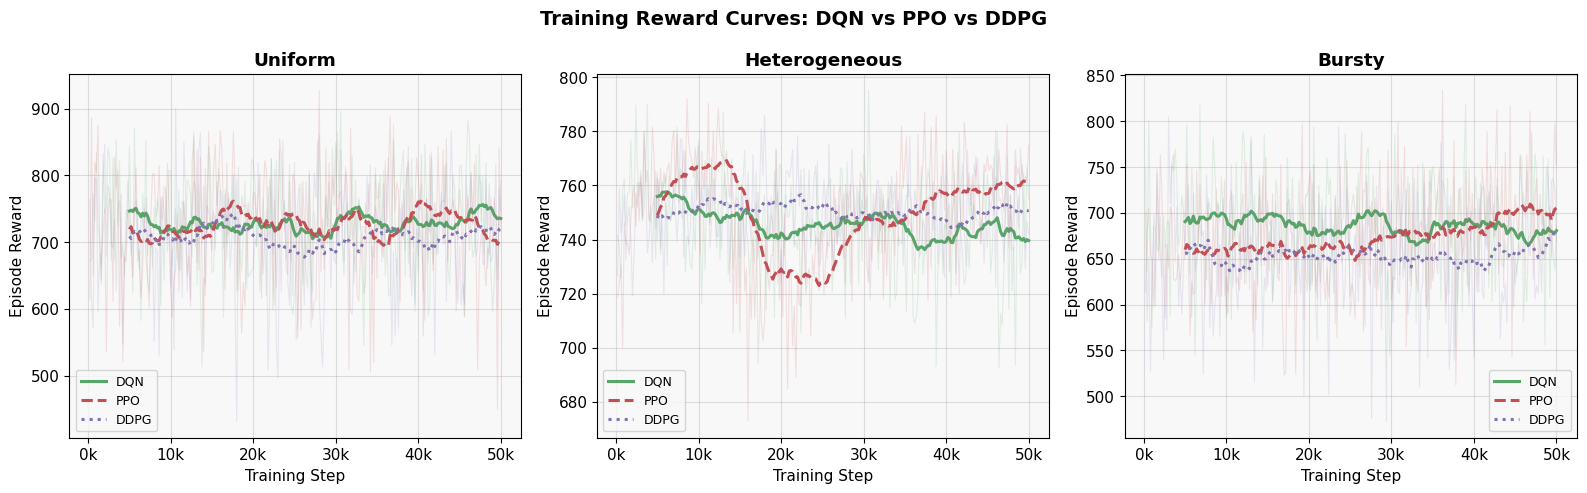

Saved comp_training_curves.png


In [5]:
# Plot 2: Training reward curves, one subplot per scenario
def smooth(y, w=8):
    if len(y) < w: return y
    return np.convolve(y, np.ones(w)/w, mode='valid')

algo_styles = {
    'DQN':  (COLORS['DQN'],  '-'),
    'PPO':  (COLORS['PPO'],  '--'),
    'DDPG': (COLORS['DDPG'], ':'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Training Reward Curves: DQN vs PPO vs DDPG',
             fontsize=14, fontweight='bold')

for col, sc in enumerate(SCENARIOS):
    ax = axes[col]
    for algo, (color, ls) in algo_styles.items():
        steps, rew = (dqn_curves[sc] if algo == 'DQN'
                      else ppo_curves[sc] if algo == 'PPO'
                      else ddpg_curves[sc])
        w  = max(3, len(rew) // 10)
        sm = smooth(rew, w)
        ax.plot(steps, rew, alpha=0.15, color=color, linewidth=0.8)
        ax.plot(steps[w-1:], sm, label=algo, color=color,
                linestyle=ls, linewidth=2.2)
    ax.set_title(sc.capitalize(), fontweight='bold')
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Episode Reward')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{int(v)//1000}k'))

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'comp_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved comp_training_curves.png')


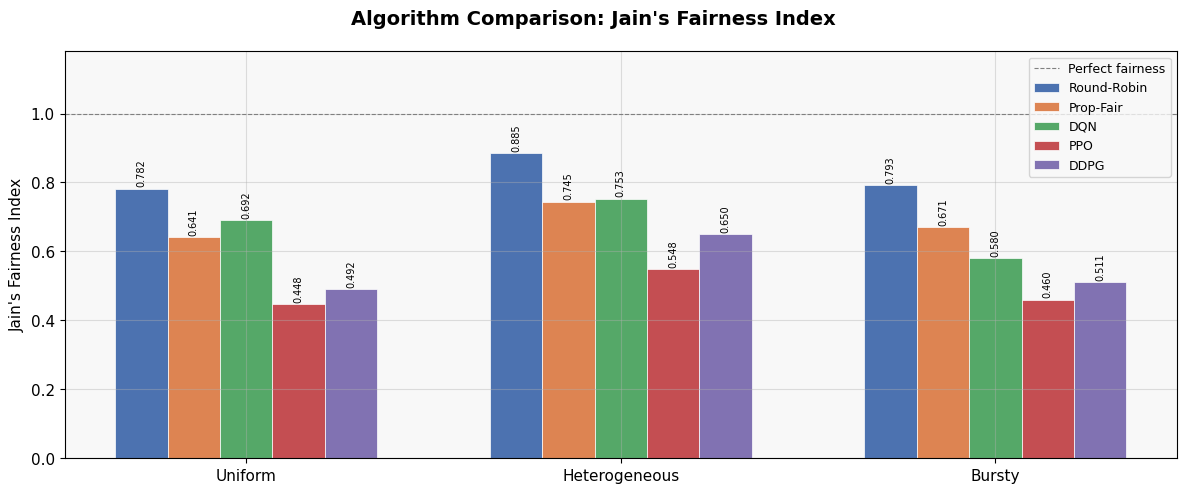

Saved comp_fairness.png


In [6]:
# Plot 3: Jain's Fairness Index
jain = {sc: {m: results[sc][m]['fairness'].mean()
             for m in METHODS}
        for sc in SCENARIOS}

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Algorithm Comparison: Jain's Fairness Index",
             fontsize=14, fontweight='bold')

for i, m in enumerate(METHODS):
    vals = [jain[sc][m] for sc in SCENARIOS]
    bars = ax.bar(x + offsets[i], vals, width,
                  label=m, color=COLORS[m], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SCENARIOS])
ax.set_ylabel("Jain's Fairness Index")
ax.set_ylim(0, 1.18)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Perfect fairness')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'comp_fairness.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved comp_fairness.png')


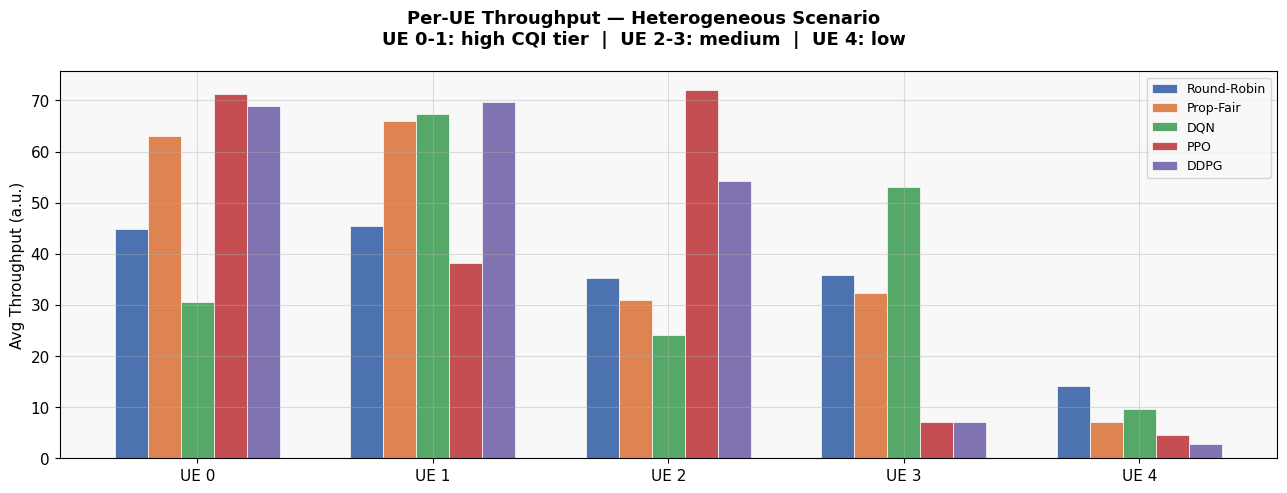

Saved comp_per_ue.png


In [7]:
# Plot 4: Per-UE throughput — heterogeneous scenario (most informative)
sc    = 'heterogeneous'
ue_x  = np.arange(N_UES)
ue_w  = 0.14
ue_off = np.linspace(-(len(METHODS)-1)/2, (len(METHODS)-1)/2, len(METHODS)) * ue_w

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Per-UE Throughput — Heterogeneous Scenario\n'
             'UE 0-1: high CQI tier  |  UE 2-3: medium  |  UE 4: low',
             fontsize=13, fontweight='bold')

for i, m in enumerate(METHODS):
    avg = results[sc][m]['throughputs'].mean(axis=0)
    ax.bar(ue_x + ue_off[i], avg, ue_w, label=m,
           color=COLORS[m], edgecolor='white', linewidth=0.5)

ax.set_xticks(ue_x)
ax.set_xticklabels([f'UE {i}' for i in range(N_UES)])
ax.set_ylabel('Avg Throughput (a.u.)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'comp_per_ue.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved comp_per_ue.png')


In [8]:
# Summary table
print('=' * 74)
print(f"{'Scenario':>15} {'Method':>12}  {'Total Tput':>11}  {'Fairness':>9}  {'vs RR':>7}  {'vs PF':>7}")
print('=' * 74)
for sc in SCENARIOS:
    rr  = results[sc]['Round-Robin']['throughputs'].sum(axis=1).mean()
    pf  = results[sc]['Prop-Fair']['throughputs'].sum(axis=1).mean()
    for m in METHODS:
        tput = results[sc][m]['throughputs'].sum(axis=1).mean()
        jain_val = results[sc][m]['fairness'].mean()
        vs_rr = (tput - rr) / rr * 100
        vs_pf = (tput - pf) / pf * 100
        print(f'{sc:>15} {m:>12}  {tput:>11.2f}  {jain_val:>9.4f}  {vs_rr:>+6.1f}%  {vs_pf:>+6.1f}%')
    print('-' * 74)


       Scenario       Method   Total Tput   Fairness    vs RR    vs PF
        uniform  Round-Robin       134.82     0.7823    +0.0%   -17.2%
        uniform    Prop-Fair       162.79     0.6414   +20.7%    +0.0%
        uniform          DQN       147.43     0.6919    +9.4%    -9.4%
        uniform          PPO       139.96     0.4481    +3.8%   -14.0%
        uniform         DDPG       135.71     0.4918    +0.7%   -16.6%
--------------------------------------------------------------------------
  heterogeneous  Round-Robin       175.78     0.8855    +0.0%   -11.8%
  heterogeneous    Prop-Fair       199.23     0.7445   +13.3%    +0.0%
  heterogeneous          DQN       184.60     0.7529    +5.0%    -7.3%
  heterogeneous          PPO       193.24     0.5480    +9.9%    -3.0%
  heterogeneous         DDPG       202.87     0.6499   +15.4%    +1.8%
--------------------------------------------------------------------------
         bursty  Round-Robin       163.31     0.7935    +0.0%   -18.2